## SQA3D test — cdViews selection for one sample

Loads a **SQA3D** (`SQA`) test item, shows the **situation** and **question**, and plots the **nine views** chosen the same way as `cdviews/qa_inference.py`:

1. **ViewSelector** scores all RGB frames (precomputed order in `SQA_test_view_ranking.json` under the `"view"` key).
2. **viewNMS** picks up to nine frames that stay diverse (pairwise pose distance &lt; `distance_threshold` removes neighbors), matching `input_views: 9` in `cfgs/QA.yaml`.

If a cached `view_distance/{scene_id}.csv` exists it is used; otherwise pairwise distances are computed from ScanNet pose files under `frames_square/{scene_id}/pose/` (no PyTorch required).

In [25]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from PIL import Image
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R


def viewNMS(
    list_of_images: list,
    neighbour_df: pd.DataFrame,
    num_images: int,
    distance_threshold: float = 0.5,
) -> list:
    """Same logic as `cdviews/qa_inference.viewNMS`."""
    selected_images = []
    remaining_images = list(list_of_images)

    while len(selected_images) < num_images and remaining_images:
        current_image = remaining_images.pop(0)
        selected_images.append(current_image)

        sorted_distances = neighbour_df.loc[current_image].sort_values()
        filtered_images = sorted_distances[sorted_distances < distance_threshold]
        neighbours_to_remove = set(filtered_images.index.tolist())
        remaining_images = [img for img in remaining_images if img not in neighbours_to_remove]

    return selected_images


def _extract_camera_pose(pose_matrix: np.ndarray):
    position = pose_matrix[:3, 3]
    orientation = R.from_matrix(pose_matrix[:3, :3])
    quaternion = orientation.as_quat()
    return position, quaternion


def _camera_distance(pose1, pose2, position_weight: float = 1.0, orientation_weight: float = 1.0) -> float:
    pos1, quat1 = pose1
    pos2, quat2 = pose2
    pos_distance = float(np.linalg.norm(pos1 - pos2))
    quat_dot_product = np.abs(np.dot(quat1, quat2))
    orientation_distance = 2 * np.arccos(np.clip(quat_dot_product, -1.0, 1.0))
    return position_weight * pos_distance + orientation_weight * orientation_distance


def _pairwise_image_distance(image_poses: dict) -> pd.DataFrame:
    poses = {img: _extract_camera_pose(pose) for img, pose in image_poses.items()}
    image_names = list(poses.keys())
    n = len(image_names)
    distance_df = pd.DataFrame(np.zeros((n, n)), index=image_names, columns=image_names)
    for i in range(n):
        for j in range(i + 1, n):
            dist = _camera_distance(poses[image_names[i]], poses[image_names[j]])
            distance_df.iloc[i, j] = dist
            distance_df.iloc[j, i] = dist
    return distance_df


def _load_pose_txt(path: Path) -> np.ndarray:
    lines = path.read_text().splitlines()
    assert len(lines) == 4
    rows = [[float(x) for x in line.split()] for line in lines]
    return np.asarray(rows, dtype=np.float32)


def compute_view_distance_df(scene_id: str, image_folder: Path) -> pd.DataFrame:
    """Pairwise pose distances for all frames in `scene_id` (matches `calculate_view_distance` in cdviews)."""
    pose_dir = image_folder / scene_id / "pose"
    pose_dict = {}
    for pose_file in sorted(pose_dir.glob("*.txt")):
        pose_info = _load_pose_txt(pose_file)
        image_name = f"{pose_file.stem}.jpg"
        pose_dict[image_name] = pose_info
    return _pairwise_image_distance(pose_dict)


def load_or_compute_distance_df(scene_id: str, image_folder: Path, view_distance_folder: Path) -> pd.DataFrame:
    cached = view_distance_folder / f"{scene_id}.csv"
    if cached.is_file():
        return pd.read_csv(cached, index_col=0)
    return compute_view_distance_df(scene_id, image_folder)

In [26]:
# --- Paths (notebook lives in scripts/)
REPO_ROOT = Path("..").resolve()
DATA_QA = REPO_ROOT / "data" / "qa"

SQA_TEST_JSON = DATA_QA / "SQA" / "SQA_test.json"
VIEW_RANKING_JSON = DATA_QA / "SQA_test_view_ranking.json"
IMAGE_FOLDER = REPO_ROOT / "data" / "qa" / "scannetv2" / "frames_square"
VIEW_DISTANCE_FOLDER = REPO_ROOT / "data" / "qa" / "scannetv2" / "view_distance"

# Match cfgs/QA.yaml
INPUT_VIEWS = 9
NMS_DISTANCE_THRESHOLD = 0.5

# Pick a row in SQA_test.json (0-based). Change freely.
SAMPLE_IDX = 0

**Scene** `scene0050_00` · **question_id** `220602000002` · **index** `0`

**Situation**  
I am standing by the ottoman on my right facing a couple of toolboxes.

**Question**  
What instrument in front of me is ebony and ivory?

*(VLM prompt uses `situation + question`, same as `qa_inference` for SQA.)*

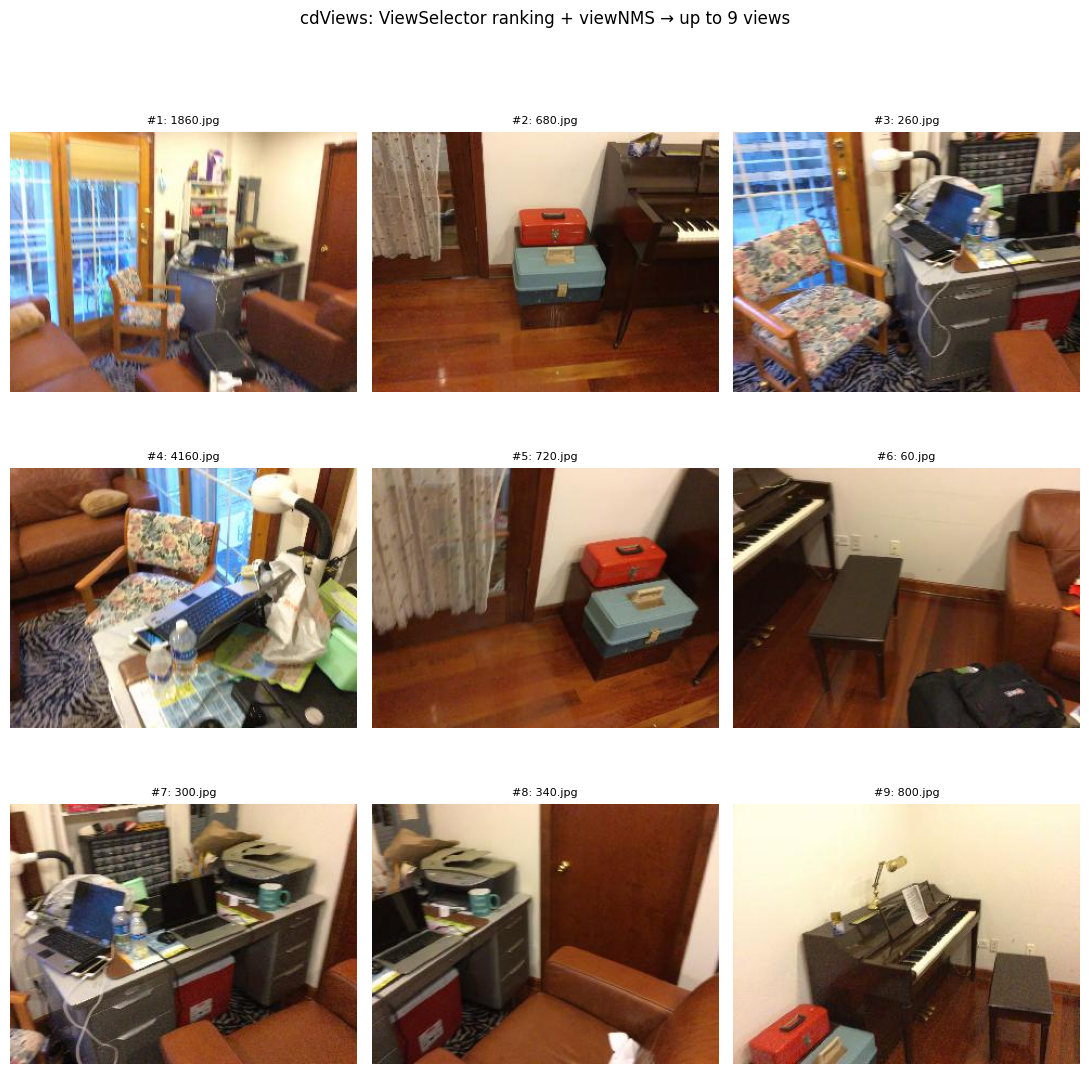

In [27]:
with open(SQA_TEST_JSON) as f:
    sqa_test = json.load(f)

with open(VIEW_RANKING_JSON) as f:
    view_ranking_data = json.load(f)

view_by_qid = view_ranking_data["view"]

sample = sqa_test[SAMPLE_IDX]
scene_id = sample["scene_id"]
question_id = sample["question_id"]
qid_str = str(question_id)

situation = sample["situation"]
question = sample["question"]

if qid_str not in view_by_qid:
    raise KeyError(
        f"question_id {qid_str} not in view ranking. "
        f"Check SAMPLE_IDX or regenerate {VIEW_RANKING_JSON.name}."
    )

ranked_full = list(view_by_qid[qid_str])
distance_df = load_or_compute_distance_df(scene_id, IMAGE_FOLDER, VIEW_DISTANCE_FOLDER)

# Restrict to rows/cols that appear in the ranking (should be a subset of all frames)
missing = [f for f in ranked_full if f not in distance_df.index]
if missing:
    raise RuntimeError(
        f"{len(missing)} ranked frame(s) missing from distance matrix, e.g. {missing[:3]}"
    )

sub_df = distance_df.loc[ranked_full, ranked_full]
selected = viewNMS(ranked_full, sub_df, num_images=INPUT_VIEWS, distance_threshold=NMS_DISTANCE_THRESHOLD)
# selected = selected[:INPUT_VIEWS]

display(
    Markdown(
        f"**Scene** `{scene_id}` · **question_id** `{question_id}` · **index** `{SAMPLE_IDX}`\n\n"
        f"**Situation**  \n{situation}\n\n"
        f"**Question**  \n{question}\n\n"
        f"*(VLM prompt uses `situation + question`, same as `qa_inference` for SQA.)*"
    )
)

color_dir = IMAGE_FOLDER / scene_id / "color"
fig, axes = plt.subplots(3, 3, figsize=(11, 11))
axes = axes.ravel()
for ax, fname, k in zip(axes, selected, range(1, len(selected) + 1)):
    path = color_dir / fname
    img = Image.open(path).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"#{k}: {fname}", fontsize=8)
    ax.axis("off")
plt.suptitle(
    "cdViews: ViewSelector ranking + viewNMS → up to 9 views",
    fontsize=12,
    y=1.02,
)
plt.tight_layout()
plt.show()

## Pixel → 3D World Coordinates (Multi-View Back-Projection)

For each selected view we:

1. **Load the depth map** (16-bit PNG, values in mm) and the **camera-to-world pose** (4×4).
2. **Back-project** every valid pixel `(u, v)` with depth `z` into the **camera frame** using the depth intrinsics:
   ```
   x_cam = (u - cx) * z / fx
   y_cam = (v - cy) * z / fy
   z_cam = z
   ```
3. **Transform** from camera to **world** using the pose matrix `T_cw`:
   ```
   p_world = R @ p_cam + t        (R = T[:3,:3], t = T[:3,3])
   ```

Because every view's pose brings points into the **same world frame**, the same physical surface point seen in different views will map to the same 3D location (up to depth-sensor noise).

In [28]:
def load_intrinsic(scene_dir: Path) -> np.ndarray:
    """Load the 4x4 depth intrinsic matrix and return the 3x3 upper-left block."""
    K4 = np.loadtxt(scene_dir / "intrinsic_depth.txt")
    return K4[:3, :3]


def load_depth(scene_dir: Path, frame_stem: str) -> np.ndarray:
    """Load a 16-bit depth map (mm) and return as float64 in metres. Invalid pixels = 0."""
    depth_path = scene_dir / "depth" / f"{frame_stem}.png"
    depth_mm = np.array(Image.open(depth_path), dtype=np.float64)
    return depth_mm / 1000.0


def load_pose(scene_dir: Path, frame_stem: str) -> np.ndarray:
    """Load the 4x4 camera-to-world pose for a frame. Returns None if the pose is invalid."""
    pose_path = scene_dir / "pose" / f"{frame_stem}.txt"
    T = np.loadtxt(pose_path)
    if not np.isfinite(T).all():
        return None
    return T


def backproject_to_world(
    depth: np.ndarray,
    K: np.ndarray,
    T_cw: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Back-project a depth map to 3D world coordinates.

    Parameters
    ----------
    depth : (H, W) depth in metres (0 = invalid).
    K     : (3, 3) depth intrinsic matrix.
    T_cw  : (4, 4) camera-to-world extrinsic (ScanNet pose format).

    Returns
    -------
    world_coords : (H, W, 3) — world XYZ for every pixel (invalid pixels get NaN).
    valid_mask   : (H, W) bool — True where depth > 0.
    """
    H, W = depth.shape
    fx, fy = K[0, 0], K[1, 1]
    cx, cy = K[0, 2], K[1, 2]

    u, v = np.meshgrid(np.arange(W, dtype=np.float64),
                        np.arange(H, dtype=np.float64))

    z = depth
    x = (u - cx) * z / fx
    y = (v - cy) * z / fy

    pts_cam = np.stack([x, y, z], axis=-1)  # (H, W, 3)

    R = T_cw[:3, :3]
    t = T_cw[:3, 3]

    # (H*W, 3) @ (3, 3)^T + (3,) → broadcast
    pts_world = (pts_cam.reshape(-1, 3) @ R.T) + t  # equivalent to R @ p + t per-point
    pts_world = pts_world.reshape(H, W, 3)

    valid_mask = depth > 0
    pts_world[~valid_mask] = np.nan

    return pts_world, valid_mask


def pixel_to_world(
    scene_dir: Path,
    frame_name: str,
    K: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Full pipeline for one frame: load depth + pose → world coordinates.

    Returns
    -------
    world_coords : (H, W, 3)
    valid_mask   : (H, W) bool
    rgb          : (H, W, 3) uint8
    """
    stem = Path(frame_name).stem  # "0.jpg" → "0"

    depth = load_depth(scene_dir, stem)
    T_cw = load_pose(scene_dir, stem)
    if T_cw is None:
        raise ValueError(f"Invalid (non-finite) pose for frame {frame_name}")

    world_coords, valid_mask = backproject_to_world(depth, K, T_cw)

    color_path = scene_dir / "color" / frame_name
    rgb = np.array(Image.open(color_path).convert("RGB"))

    return world_coords, valid_mask, rgb


print("Back-projection helpers loaded.")

Back-projection helpers loaded.


In [29]:
scene_dir = IMAGE_FOLDER / scene_id
K = load_intrinsic(scene_dir)
print(f"Scene: {scene_id}")
print(f"Intrinsic K:\n{K}")
print(f"Selected views ({len(selected)}): {selected}\n")

all_points = []   # (N, 3) world XYZ
all_colors = []   # (N, 3) uint8 RGB
per_view = {}     # frame_name → { world_coords, valid_mask, rgb }

for frame_name in selected:
    world_coords, valid_mask, rgb = pixel_to_world(scene_dir, frame_name, K)

    pts = world_coords[valid_mask]        # (n, 3)
    cols = rgb[valid_mask]                 # (n, 3)
    all_points.append(pts)
    all_colors.append(cols)

    per_view[frame_name] = dict(
        world_coords=world_coords,
        valid_mask=valid_mask,
        rgb=rgb,
    )

    n_valid = valid_mask.sum()
    n_total = valid_mask.size
    print(f"  {frame_name:>12s}: {n_valid:,} / {n_total:,} valid pixels "
          f"({100*n_valid/n_total:.1f}%)")

fused_xyz = np.concatenate(all_points, axis=0)   # (M, 3)
fused_rgb = np.concatenate(all_colors, axis=0)    # (M, 3)

print(f"\nFused point cloud: {fused_xyz.shape[0]:,} points from {len(selected)} views")
print(f"  World XYZ range: min {fused_xyz.min(axis=0)}, max {fused_xyz.max(axis=0)}")

Scene: scene0050_00
Intrinsic K:
[[577.871   0.    319.5  ]
 [  0.    577.871 239.5  ]
 [  0.      0.      1.   ]]
Selected views (9): ['1860.jpg', '680.jpg', '260.jpg', '4160.jpg', '720.jpg', '60.jpg', '300.jpg', '340.jpg', '800.jpg']

      1860.jpg: 69,850 / 76,800 valid pixels (91.0%)
       680.jpg: 73,395 / 76,800 valid pixels (95.6%)
       260.jpg: 65,695 / 76,800 valid pixels (85.5%)
      4160.jpg: 67,207 / 76,800 valid pixels (87.5%)
       720.jpg: 73,402 / 76,800 valid pixels (95.6%)


        60.jpg: 73,288 / 76,800 valid pixels (95.4%)
       300.jpg: 70,070 / 76,800 valid pixels (91.2%)
       340.jpg: 71,961 / 76,800 valid pixels (93.7%)
       800.jpg: 72,338 / 76,800 valid pixels (94.2%)

Fused point cloud: 637,206 points from 9 views
  World XYZ range: min [-1.88004497  0.22484337  0.28541554], max [8.35200271 4.24114466 2.24886871]


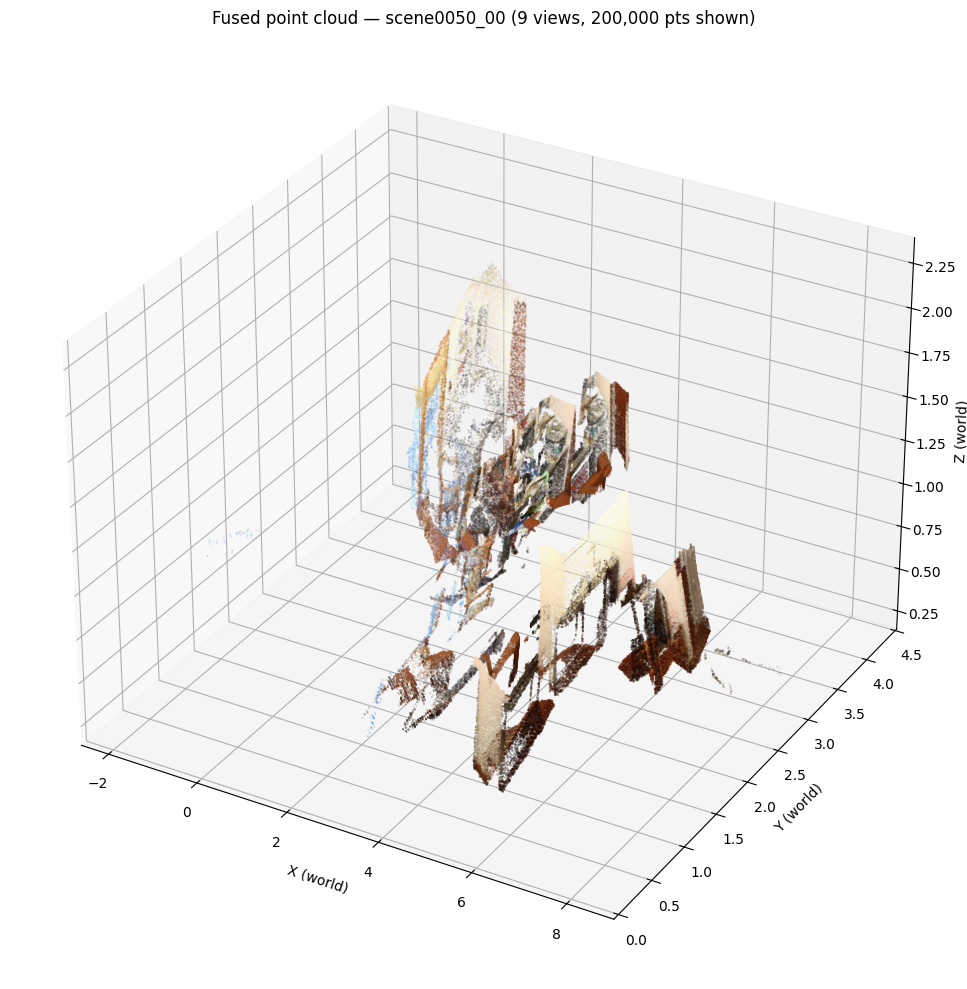

In [30]:
# --- 3D scatter: fused point cloud coloured by RGB ---
# Subsample for plotting speed (matplotlib can't handle millions of points)
MAX_PLOT_PTS = 200_000
rng = np.random.default_rng(42)
if fused_xyz.shape[0] > MAX_PLOT_PTS:
    idx = rng.choice(fused_xyz.shape[0], MAX_PLOT_PTS, replace=False)
    plot_xyz = fused_xyz[idx]
    plot_rgb = fused_rgb[idx]
else:
    plot_xyz = fused_xyz
    plot_rgb = fused_rgb

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    plot_xyz[:, 0],
    plot_xyz[:, 1],
    plot_xyz[:, 2],
    c=plot_rgb / 255.0,
    s=0.1,
    marker=".",
)
ax.set_xlabel("X (world)")
ax.set_ylabel("Y (world)")
ax.set_zlabel("Z (world)")
ax.set_title(f"Fused point cloud — {scene_id} ({len(selected)} views, "
             f"{plot_xyz.shape[0]:,} pts shown)")
plt.tight_layout()
plt.show()

In [31]:
# --- Multi-view consistency check ---
# For each pair of views, find pixels that map to nearby 3D locations.
# If back-projection is correct, overlapping regions should agree.

from scipy.spatial import cKDTree

CONSISTENCY_THRESHOLD_M = 0.02  # 2 cm — points closer than this are "consistent"

view_names = list(per_view.keys())
print("Multi-view consistency check (pairwise overlap via 3D nearest-neighbour):\n")

for i in range(min(3, len(view_names))):
    for j in range(i + 1, min(4, len(view_names))):
        name_a, name_b = view_names[i], view_names[j]
        va, vb = per_view[name_a], per_view[name_b]

        pts_a = va["world_coords"][va["valid_mask"]]
        pts_b = vb["world_coords"][vb["valid_mask"]]

        # Subsample for speed
        n_sub = min(20_000, len(pts_a), len(pts_b))
        idx_a = rng.choice(len(pts_a), n_sub, replace=False)
        idx_b = rng.choice(len(pts_b), n_sub, replace=False)

        tree_b = cKDTree(pts_b[idx_b])
        dists, _ = tree_b.query(pts_a[idx_a], k=1)

        n_close = (dists < CONSISTENCY_THRESHOLD_M).sum()
        pct = 100 * n_close / n_sub

        print(f"  {name_a} ↔ {name_b}: "
              f"{n_close:,}/{n_sub:,} pts within {CONSISTENCY_THRESHOLD_M*100:.0f} cm "
              f"({pct:.1f}% overlap)")

print("\n(Higher overlap % between nearby views confirms multi-view consistency.)")

Multi-view consistency check (pairwise overlap via 3D nearest-neighbour):

  1860.jpg ↔ 680.jpg: 0/20,000 pts within 2 cm (0.0% overlap)
  1860.jpg ↔ 260.jpg: 61/20,000 pts within 2 cm (0.3% overlap)
  1860.jpg ↔ 4160.jpg: 13/20,000 pts within 2 cm (0.1% overlap)
  680.jpg ↔ 260.jpg: 0/20,000 pts within 2 cm (0.0% overlap)
  680.jpg ↔ 4160.jpg: 0/20,000 pts within 2 cm (0.0% overlap)
  260.jpg ↔ 4160.jpg: 1,129/20,000 pts within 2 cm (5.6% overlap)

(Higher overlap % between nearby views confirms multi-view consistency.)


In [32]:
selected

['1860.jpg',
 '680.jpg',
 '260.jpg',
 '4160.jpg',
 '720.jpg',
 '60.jpg',
 '300.jpg',
 '340.jpg',
 '800.jpg']

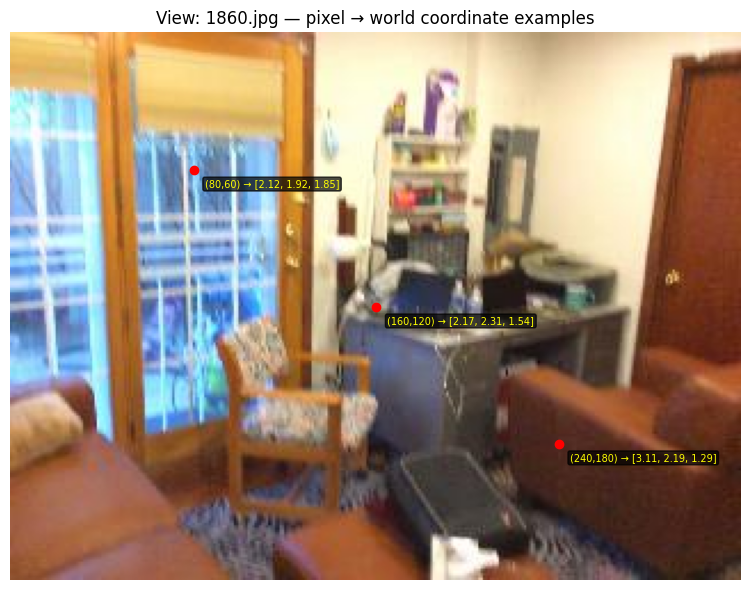


World-coordinate map shape: (240, 320, 3)  (index as world_coords[v, u] for pixel (u, v))
Valid pixels: 69,850 / 76,800


In [33]:
# --- Per-pixel world coordinate lookup demo ---
# Show that for any pixel (u, v) in any view, we can retrieve its 3D world location.

demo_frame = selected[0]
wc = per_view[demo_frame]["world_coords"]     # (H, W, 3)
vm = per_view[demo_frame]["valid_mask"]        # (H, W)
rgb_img = per_view[demo_frame]["rgb"]          # (H, W, 3)

H, W = wc.shape[:2]
demo_pixels = [(W // 2, H // 2), (W // 4, H // 4), (3 * W // 4, 3 * H // 4)]

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.imshow(rgb_img)
ax.set_title(f"View: {demo_frame} — pixel → world coordinate examples")

for (u, v) in demo_pixels:
    if vm[v, u]:
        xyz = wc[v, u]
        label = f"({u},{v}) → [{xyz[0]:.2f}, {xyz[1]:.2f}, {xyz[2]:.2f}]"
        ax.plot(u, v, "ro", markersize=6)
        ax.annotate(label, (u, v), textcoords="offset points", xytext=(8, -12),
                    fontsize=7, color="yellow",
                    bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.7))
    else:
        ax.plot(u, v, "rx", markersize=8)
        ax.annotate(f"({u},{v}) → invalid depth", (u, v),
                    textcoords="offset points", xytext=(8, -12),
                    fontsize=7, color="red",
                    bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.7))

ax.axis("off")
plt.tight_layout()
plt.show()

print(f"\nWorld-coordinate map shape: {wc.shape}  "
      f"(index as world_coords[v, u] for pixel (u, v))")
print(f"Valid pixels: {vm.sum():,} / {vm.size:,}")

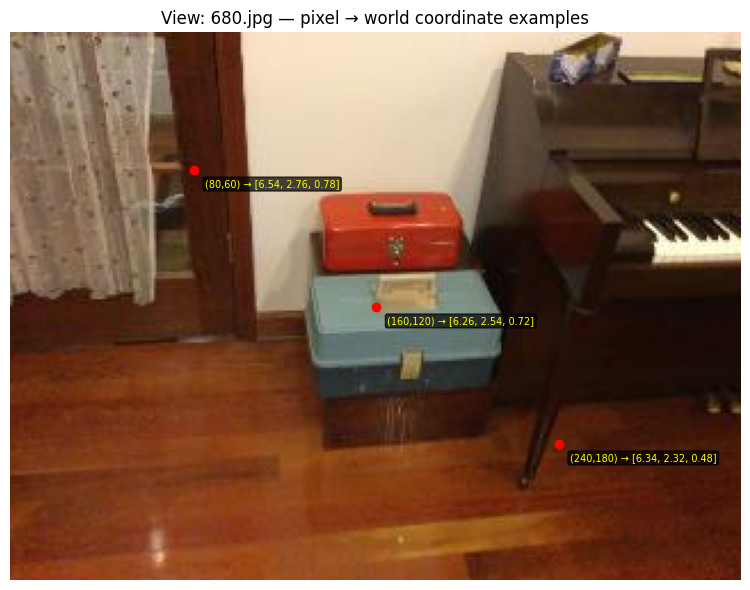


World-coordinate map shape: (240, 320, 3)  (index as world_coords[v, u] for pixel (u, v))
Valid pixels: 73,395 / 76,800


In [34]:
# --- Per-pixel world coordinate lookup demo ---
# Show that for any pixel (u, v) in any view, we can retrieve its 3D world location.

demo_frame = selected[1]
wc = per_view[demo_frame]["world_coords"]     # (H, W, 3)
vm = per_view[demo_frame]["valid_mask"]        # (H, W)
rgb_img = per_view[demo_frame]["rgb"]          # (H, W, 3)

H, W = wc.shape[:2]
demo_pixels = [(W // 2, H // 2), (W // 4, H // 4), (3 * W // 4, 3 * H // 4)]

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.imshow(rgb_img)
ax.set_title(f"View: {demo_frame} — pixel → world coordinate examples")

for (u, v) in demo_pixels:
    if vm[v, u]:
        xyz = wc[v, u]
        label = f"({u},{v}) → [{xyz[0]:.2f}, {xyz[1]:.2f}, {xyz[2]:.2f}]"
        ax.plot(u, v, "ro", markersize=6)
        ax.annotate(label, (u, v), textcoords="offset points", xytext=(8, -12),
                    fontsize=7, color="yellow",
                    bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.7))
    else:
        ax.plot(u, v, "rx", markersize=8)
        ax.annotate(f"({u},{v}) → invalid depth", (u, v),
                    textcoords="offset points", xytext=(8, -12),
                    fontsize=7, color="red",
                    bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.7))

ax.axis("off")
plt.tight_layout()
plt.show()

print(f"\nWorld-coordinate map shape: {wc.shape}  "
      f"(index as world_coords[v, u] for pixel (u, v))")
print(f"Valid pixels: {vm.sum():,} / {vm.size:,}")

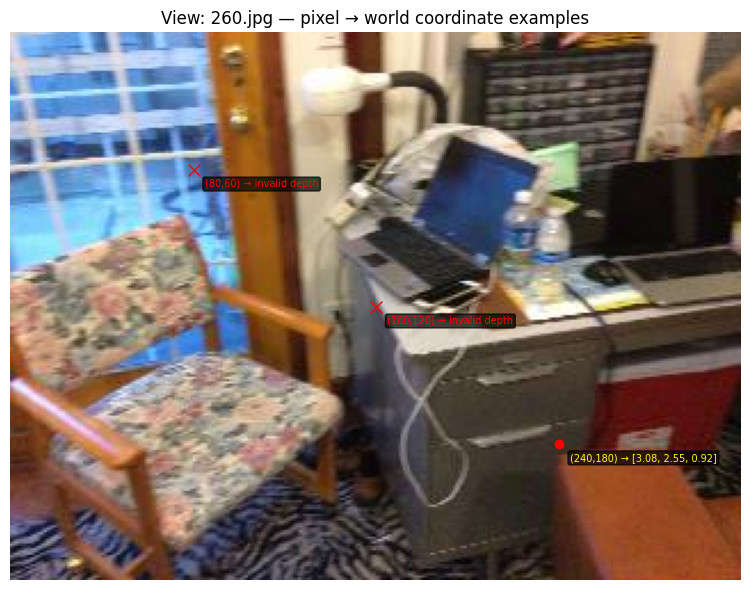


World-coordinate map shape: (240, 320, 3)  (index as world_coords[v, u] for pixel (u, v))
Valid pixels: 65,695 / 76,800


In [35]:
# --- Per-pixel world coordinate lookup demo ---
# Show that for any pixel (u, v) in any view, we can retrieve its 3D world location.

demo_frame = selected[2]
wc = per_view[demo_frame]["world_coords"]     # (H, W, 3)
vm = per_view[demo_frame]["valid_mask"]        # (H, W)
rgb_img = per_view[demo_frame]["rgb"]          # (H, W, 3)

H, W = wc.shape[:2]
demo_pixels = [(W // 2, H // 2), (W // 4, H // 4), (3 * W // 4, 3 * H // 4)]

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.imshow(rgb_img)
ax.set_title(f"View: {demo_frame} — pixel → world coordinate examples")

for (u, v) in demo_pixels:
    if vm[v, u]:
        xyz = wc[v, u]
        label = f"({u},{v}) → [{xyz[0]:.2f}, {xyz[1]:.2f}, {xyz[2]:.2f}]"
        ax.plot(u, v, "ro", markersize=6)
        ax.annotate(label, (u, v), textcoords="offset points", xytext=(8, -12),
                    fontsize=7, color="yellow",
                    bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.7))
    else:
        ax.plot(u, v, "rx", markersize=8)
        ax.annotate(f"({u},{v}) → invalid depth", (u, v),
                    textcoords="offset points", xytext=(8, -12),
                    fontsize=7, color="red",
                    bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.7))

ax.axis("off")
plt.tight_layout()
plt.show()

print(f"\nWorld-coordinate map shape: {wc.shape}  "
      f"(index as world_coords[v, u] for pixel (u, v))")
print(f"Valid pixels: {vm.sum():,} / {vm.size:,}")

In [36]:
def plot_grid_3d_coords(
    rgb: np.ndarray,
    world_coords: np.ndarray,
    valid_mask: np.ndarray,
    grid_step: int = 30,
    title: str = "",
    ax=None,
):
    """
    Overlay a grid of 3D world-coordinate labels on an RGB image.

    Parameters
    ----------
    rgb          : (H, W, 3) uint8 image.
    world_coords : (H, W, 3) world XYZ per pixel (NaN where invalid).
    valid_mask   : (H, W) bool.
    grid_step    : spacing in pixels between sample points.
    title        : plot title.
    ax           : optional matplotlib Axes; one is created if None.

    Returns
    -------
    ax : the Axes used.
    """
    H, W = rgb.shape[:2]
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(1, 1, figsize=(10, 7.5))

    ax.imshow(rgb)

    for v in range(grid_step // 2, H, grid_step):
        for u in range(grid_step // 2, W, grid_step):
            if valid_mask[v, u]:
                xyz = world_coords[v, u]
                label = f"{xyz[0]:.2f},{xyz[1]:.2f},{xyz[2]:.2f}"
                ax.plot(u, v, "o", color="lime", markersize=3)
                ax.annotate(
                    label, (u, v),
                    textcoords="offset points", xytext=(4, -4),
                    fontsize=4, color="white",
                    bbox=dict(boxstyle="round,pad=0.15", fc="black", alpha=0.6, lw=0),
                )
            else:
                ax.plot(u, v, "x", color="red", markersize=3)

    ax.set_title(title, fontsize=10)
    ax.axis("off")
    if own_fig:
        plt.tight_layout()
    return ax


print("plot_grid_3d_coords() defined.")

plot_grid_3d_coords() defined.


Scene scene0050_00: 233 total frames
Adjacent frames: ['0.jpg', '20.jpg', '40.jpg', '60.jpg']



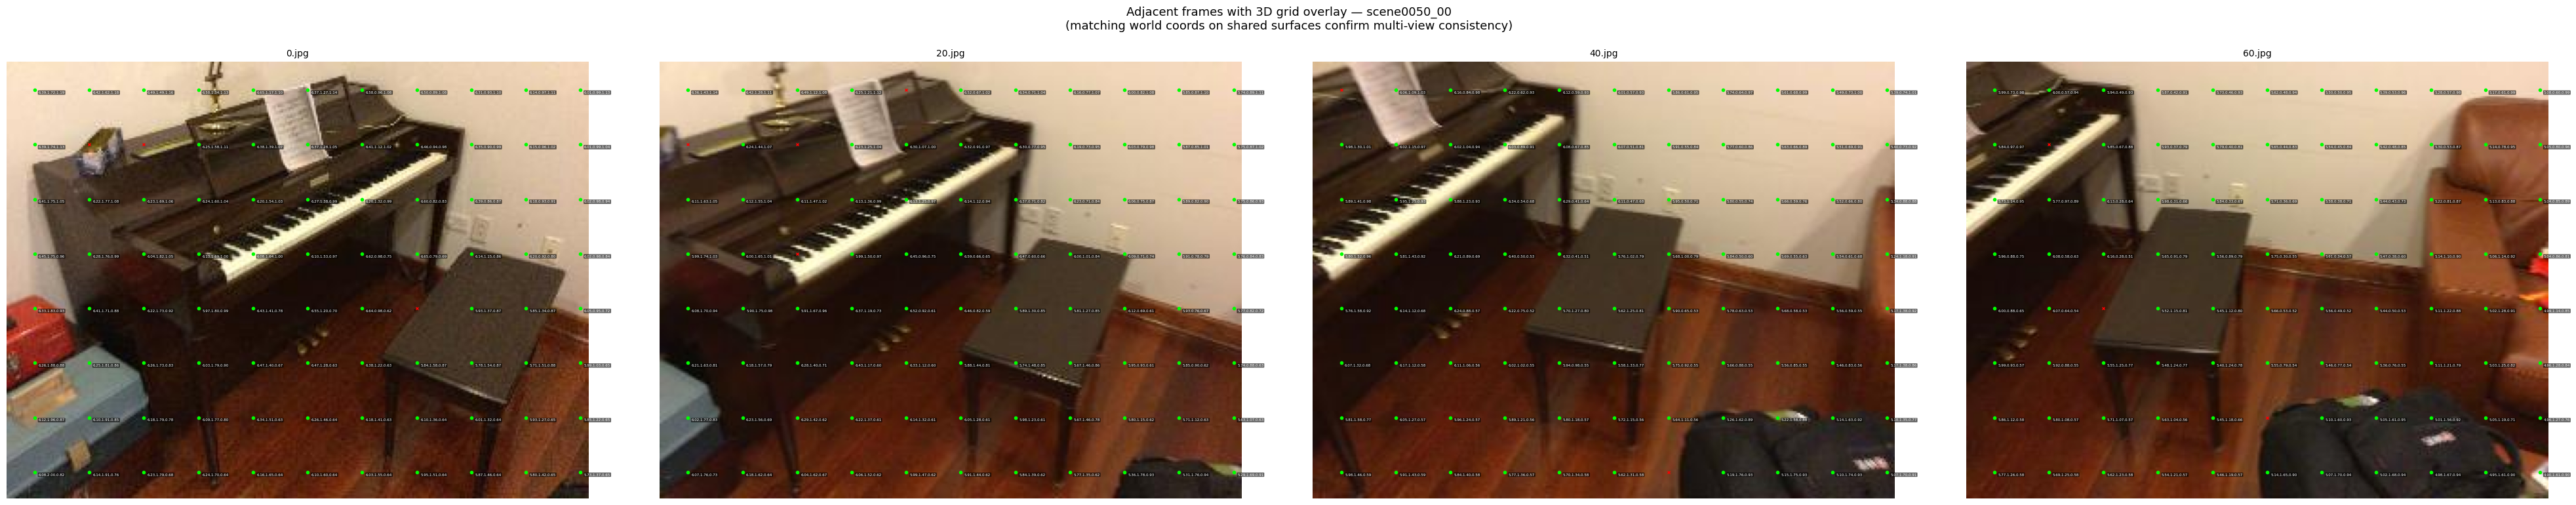

In [37]:
all_frames = sorted(
    [f.name for f in (scene_dir / "color").glob("*.jpg")],
    key=lambda n: int(Path(n).stem),
)
START = 0          # change to explore different parts of the sequence
N_CONSECUTIVE = 4  # number of adjacent frames to show
GRID_STEP = 30     # pixel spacing for the coordinate grid
consecutive = all_frames[START : START + N_CONSECUTIVE]
print(f"Scene {scene_id}: {len(all_frames)} total frames")
print(f"Adjacent frames: {consecutive}\n")
consec_data = {}
for frame_name in consecutive:
    stem = Path(frame_name).stem
    depth = load_depth(scene_dir, stem)
    T_cw = load_pose(scene_dir, stem)
    if T_cw is None:
        print(f"  {frame_name}: skipped (invalid pose)")
        continue
    wc, vm = backproject_to_world(depth, K, T_cw)
    rgb = np.array(Image.open(scene_dir / "color" / frame_name).convert("RGB"))
    consec_data[frame_name] = dict(world_coords=wc, valid_mask=vm, rgb=rgb)
n = len(consec_data)
fig, axes = plt.subplots(1, n, figsize=(10 * n, 7.5))
if n == 1:
    axes = [axes]
for ax, (fname, d) in zip(axes, consec_data.items()):
    plot_grid_3d_coords(
        d["rgb"], d["world_coords"], d["valid_mask"],
        grid_step=GRID_STEP,
        title=fname,
        ax=ax,
    )
plt.suptitle(
    f"Adjacent frames with 3D grid overlay — {scene_id}\n"
    "(matching world coords on shared surfaces confirm multi-view consistency)",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()
